# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [ ]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

## Carregue os dados

In [ ]:
# Carregue os arquivos de dados em diferentes DataFrames
df_calls = pd.read_csv('megaline_calls.csv')
df_internet = pd.read_csv('megaline_internet.csv')
df_messages = pd.read_csv('megaline_messages.csv')
df_plans = pd.read_csv('megaline_plans.csv')
df_users = pd.read_csv('megaline_users.csv')

## Prepare os dados

## Planos

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Imprima uma amostra de dados dos planos
df_plans.sample()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf


Não foram encontrados dados ausentes. Os nomes das colunas seguem o padrão snake case e seria mais adequado algumas mudanças nos tipos de dados das colunas plan_name, usd_per_gb, usd_monthly_pay. Também seria razoável alterar a coluna mb_per_month_included para gb_per_month_included com mudança também nos dados.

## Corrija os dados

In [ ]:
df_plans['usd_monthly_pay'] = df_plans['usd_monthly_pay'].astype('float')
df_plans['usd_per_gb'] = df_plans['usd_per_gb'].astype('float')
df_plans['plan_name'] = df_plans['plan_name'].astype('category')
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   messages_included      2 non-null      int64   
 1   mb_per_month_included  2 non-null      int64   
 2   minutes_included       2 non-null      int64   
 3   usd_monthly_pay        2 non-null      float64 
 4   usd_per_gb             2 non-null      float64 
 5   usd_per_message        2 non-null      float64 
 6   usd_per_minute         2 non-null      float64 
 7   plan_name              2 non-null      category
dtypes: category(1), float64(4), int64(3)
memory usage: 366.0 bytes


## Enriqueça os dados

In [ ]:
df_plans['mb_per_month_included'] = df_plans['mb_per_month_included'] / 1024
df_plans = df_plans.rename(columns={'mb_per_month_included':'gb_per_month_included'})

## Usuários

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Imprima uma amostra de dados dos usuários
print(df_users.sample(5))

     user_id first_name last_name  age  \
487     1487      Elton   Simpson   18   
343     1343    Teresia     Ewing   43   
396     1396    Ardelia    Benton   65   
458     1458     Joella     Munoz   32   
191     1191       Zack    Waters   75   

                                              city    reg_date      plan  \
487                  Cape Coral-Fort Myers, FL MSA  2018-08-16  ultimate   
343  Miami-Fort Lauderdale-West Palm Beach, FL MSA  2018-08-23      surf   
396                         Salt Lake City, UT MSA  2018-06-01      surf   
458                Detroit-Warren-Dearborn, MI MSA  2018-07-24  ultimate   
191                           St. Louis, MO-IL MSA  2018-01-21  ultimate   

     churn_date  
487         NaN  
343         NaN  
396         NaN  
458         NaN  
191  2018-11-30  


Foram encontrados valores nulos (o que era esperado dado a dinâmica da construção da tabela.) Os nomes das colunas seguem o padrão snake case e seria mais adequado algumas mudanças nos tipos de dados das colunas user_id, reg_date, plan e churn_date.

### Corrija os dados

In [ ]:
df_users['plan'] = df_users['plan'].astype('category')
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], errors='coerce')
df_users['user_id'] = df_users['user_id'].astype('object')

### Enriqueça os dados

## Chamadas

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Imprima uma amostra de dados das chamadas
df_calls.sample(5)

,id,user_id,call_date,duration
93091,1334_459,1334,2018-05-31,9.01
43954,1159_550,1159,2018-08-31,12.00
114061,1400_407,1400,2018-04-17,4.75
108987,1385_57,1385,2018-09-07,3.03
22654,1082_757,1082,2018-11-19,11.97


Não foram encontrados valores nulos. Os nomes das colunas seguem o padrão snake case e seria mais adequado algumas mudanças nos tipos de dados das colunas user_id, call_date, id.

### Corrija os dados

In [ ]:
df_calls['id'] = df_calls['id'].astype('object')
df_calls['user_id'] = df_calls['user_id'].astype('object')
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

### Enriqueça os dados

## Mensagens

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprima uma amostra dos dados das mensagens
df_messages.sample(5)

,id,user_id,message_date
32278,1200_18,1200,2018-12-08
43752,1291_55,1291,2018-08-13
4450,1043_721,1043,2018-07-02
21219,1132_472,1132,2018-08-22
2375,1028_286,1028,2018-04-01


Não foram encontrados valores nulos. Os nomes das colunas seguem o padrão snake
case e seria mais adequado algumas mudanças nos tipos de dados das colunas user_id, message_date.

### Corrija os dados

In [ ]:
df_messages['user_id'] = df_messages['user_id'].astype('object')
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

### Enriqueça os dados

## Internet

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
#  Imprima uma amostra de dados para o tráfego da internet
df_internet.sample(5)

,id,user_id,session_date,mb_used
86915,1403_263,1403,2018-12-19,711.06
77416,1362_84,1362,2018-05-03,482.13
19926,1090_159,1090,2018-06-10,661.53
53353,1240_325,1240,2018-07-17,282.75
82843,1387_59,1387,2018-10-01,0.00


Não foram encontrados valores nulos. Os nomes das colunas seguem o padrão snake case e seria mais adequado algumas mudanças nos tipos de dados das colunas user_id, session_date.

### Corrija os dados

In [ ]:
df_internet['user_id'] = df_internet['user_id'].astype('object')
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

### Enriqueça os dados

## Estude as condições dos planos

In [ ]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
df_plans

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20.0,10.0,0.03,0.03,surf
1,1000,30.0,3000,70.0,7.0,0.01,0.01,ultimate


## Agregue os dados por usuário



In [ ]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
df_calls['month'] = df_calls['call_date'].dt.month
calls_agg = df_calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_agg = calls_agg.rename(columns={'id':'total_callings'})

In [ ]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
minutes_agg = df_calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_agg = minutes_agg.rename(columns={'duration':'total_minutes'})

In [ ]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
df_messages['month'] = df_messages['message_date'].dt.month
messages_agg = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_agg = messages_agg.rename(columns={'id':'total_messages'})

In [ ]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
df_internet['month'] = df_internet['session_date'].dt.month
internet_agg = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_agg['mb_used'] = internet_agg['mb_used'] / 1024
internet_agg = internet_agg.rename(columns={'mb_used':'total_gb'})

In [ ]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
df_merged = calls_agg.merge(minutes_agg, on=['user_id', 'month'], how='outer')
df_merged = df_merged.merge(messages_agg, on=['user_id', 'month'], how='outer')
df_merged = df_merged.merge(internet_agg, on=['user_id', 'month'], how='outer')
df_merged = df_merged.fillna(0)

In [ ]:
# Adicione as informações sobre o plano
user_plans = df_users[['user_id', 'plan']]
df_merged = df_merged.merge(user_plans, on='user_id')

In [ ]:
# Calcule a receita mensal para cada usuário
def income(row):
  plan = row['plan']
  minutes = row['total_minutes']
  messages = row['total_messages']
  gbs = row['total_gb']
  sum = 0

  if plan == 'surf':
    sum = 20
    if minutes - 500 > 0:
      sum += (minutes - 500) * 0.03
    if messages - 50 > 0:
      sum += (messages - 50) * 0.03
    if gbs - 15 > 0:
      sum += (gbs - 15) * 10
    return sum
  else:
    sum = 70
    if minutes - 3000 > 0:
      sum += (minutes - 3000) * 0.01
    if messages - 1000 > 0:
      sum += (messages - 1000) * 0.01
    if gbs - 30 > 0:
      sum += (gbs - 30) * 7
    return sum

df_ceiled = df_merged.copy()
df_ceiled['total_minutes'] = np.ceil(df_ceiled['total_minutes'])
df_ceiled['total_gb'] = np.ceil(df_ceiled['total_gb'])
df_merged['income'] = df_ceiled.apply(income, axis=1)

In [ ]:
df_merged.groupby('plan')['income'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,60.331933,55.263890,20.0,20.0,40.15,80.0,588.66
ultimate,720.0,72.313889,11.395108,70.0,70.0,70.00,70.0,182.00


## Estude o comportamento do usuário

### Chamadas

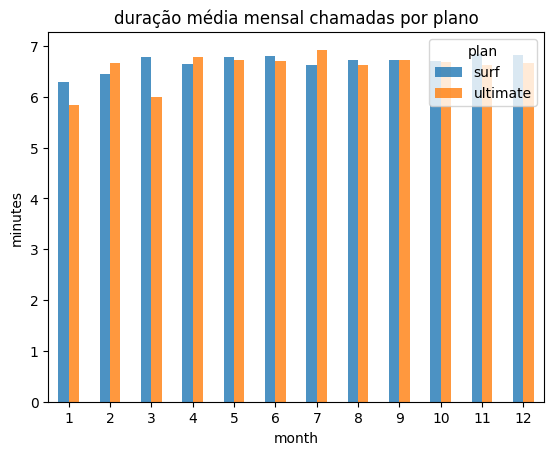

In [ ]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
df_merged['minutes_per_calling'] = df_merged['total_minutes'] / df_merged['total_callings']

mean_callings_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='minutes_per_calling',
    aggfunc='mean'
)

mean_callings_pivot.plot(
    kind='bar',
    alpha=0.8,
    rot=360,
    ylabel='minutes',
    title='duração média mensal chamadas por plano'
)

plt.show()

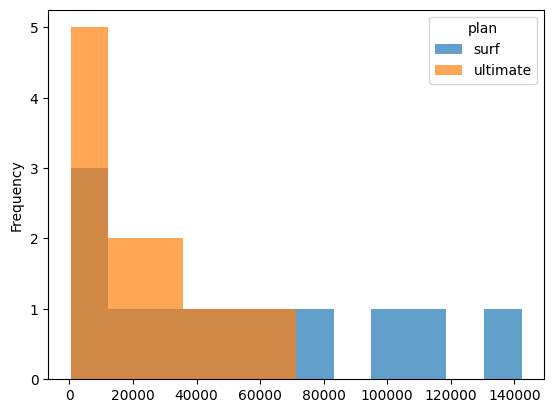

In [ ]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
sum_minutes_pivot = df_merged.pivot_table(
    index='month',
    values='total_minutes',
    columns='plan',
    aggfunc='sum'
)

sum_minutes_pivot.plot(
    kind='hist',
    alpha=0.7,
    bins=12
)

plt.show()

In [ ]:
mean_callings_pivot = mean_callings_pivot.rename(columns={'surf' : 'surf_mean', 'ultimate' : 'ultimate_mean'})

var_callings_pivot = df_merged.pivot_table(
    columns='plan',
    index='month',
    values='minutes_per_calling',
    aggfunc=np.var
)

var_callings_pivot = var_callings_pivot.rename(columns={'surf': 'surf_var', 'ultimate' : 'ultimate_var'})

callings_concat = pd.concat([mean_callings_pivot, var_callings_pivot], axis='columns')
callings_concat['general_mean'] = df_merged.groupby('month')['minutes_per_calling'].mean()
callings_concat['general_var'] = df_merged.groupby('month')['minutes_per_calling'].agg(np.var)

<AxesSubplot:xlabel='general_mean'>

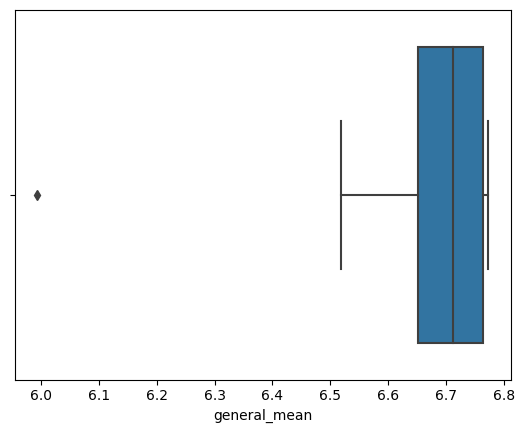

In [ ]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
sns.boxplot(callings_concat['general_mean'])

Ao analisar o tempo médio de minutos por chamada de cada plano por mês, foram encontradas poucas diferenças, sendo as mais significativas acontecendo nos três primeiros meses do ano (sendo de 30s a 1m).
Quanto ao número de minutos que os usuários de cada plano necessitam a cada mês, em números absolutos e médios, os usuários do plano Surf possuem disparidade.

### Mensagens

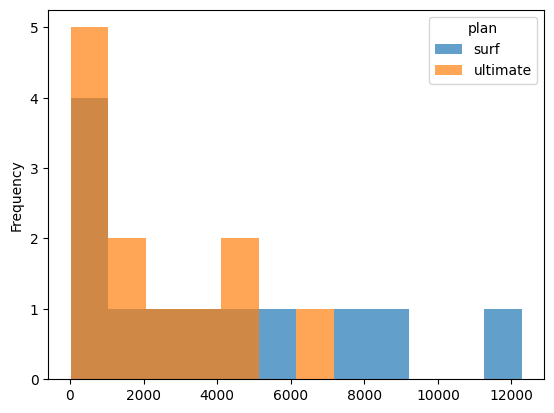

In [ ]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
sum_messages_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='total_messages',
    aggfunc='sum'
)

sum_messages_pivot.plot(
    kind='hist',
    alpha=0.7,
    bins=12
)

plt.show()

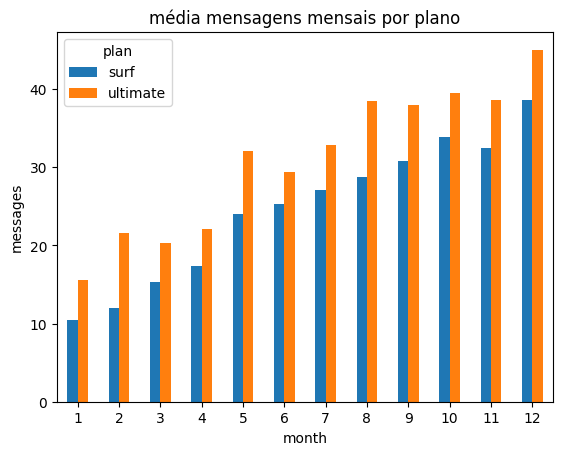

In [ ]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
mean_messages_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='total_messages',
    aggfunc='mean'
)

mean_messages_pivot.plot(
    kind='bar',
    rot=360,
    ylabel='messages',
    title='média mensagens mensais por plano'
)

plt.show()

In [ ]:
mean_messages_pivot = mean_messages_pivot.rename(columns={'surf' : 'surf_mean', 'ultimate' : 'ultimate_mean'})

var_messages_pivot = df_merged.pivot_table(
    columns='plan',
    index='month',
    values='total_messages',
    aggfunc=np.var
)

var_messages_pivot = var_messages_pivot.rename(columns={'surf': 'surf_var', 'ultimate' : 'ultimate_var'})

messages_concat = pd.concat([mean_messages_pivot, var_messages_pivot], axis='columns')
messages_concat['general_mean'] = df_merged.groupby('month')['total_messages'].mean()
messages_concat['general_var'] = df_merged.groupby('month')['total_messages'].agg(np.var)
messages_concat

plan,surf_mean,ultimate_mean,surf_var,ultimate_var,general_mean,general_var
month,,,,,,
1,10.500000,15.500000,220.500000,313.666667,13.833333,238.966667
2,12.000000,21.571429,386.000000,478.285714,16.187500,421.229167
3,15.260870,20.250000,346.565217,654.386364,16.971429,441.734454
4,17.400000,22.047619,501.591837,544.147619,18.774648,511.148491
5,24.012987,32.103448,847.197198,1297.310345,26.226415,972.291105
6,25.298969,29.340426,914.920103,857.620722,26.618056,893.706245
7,27.033058,32.830508,923.915565,960.488019,28.933333,938.051397
8,28.777778,38.478873,1029.515528,1196.367404,31.733906,1095.446130
9,30.762887,37.895349,1003.829496,1050.918331,32.953571,1025.442281


Ao analisar a média de mensagens mensais de cada plano, foram encontradas disparidades na maior parte do ano, sendo por parte dos usuários do plano Ultimate.

### Internet

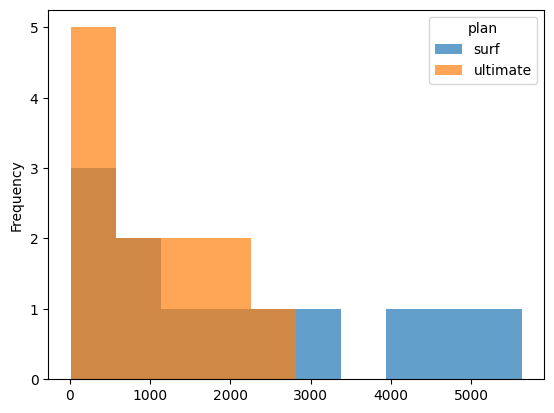

In [ ]:
sum_gbs_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='total_gb',
    aggfunc='sum'
)

sum_gbs_pivot.plot(
    kind='hist',
    alpha=0.7
)

plt.show()

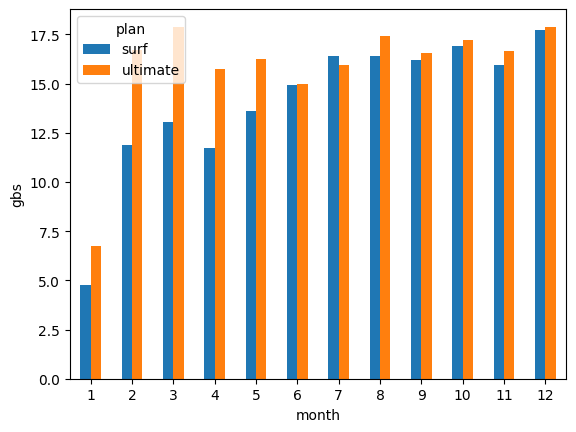

In [ ]:
mean_gbs_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='total_gb',
    aggfunc='mean'
)

mean_gbs_pivot.plot(
    kind='bar',
    rot=360,
    ylabel='gbs'
)

plt.show()

In [ ]:
mean_gbs_pivot = mean_gbs_pivot.rename(columns={'surf' : 'surf_mean', 'ultimate' : 'ultimate_mean'})

var_gbs_pivot = df_merged.pivot_table(
    columns='plan',
    index='month',
    values='total_gb',
    aggfunc=np.var
)

var_gbs_pivot = var_gbs_pivot.rename(columns={'surf': 'surf_var', 'ultimate' : 'ultimate_var'})

gbs_concat = pd.concat([mean_gbs_pivot, var_gbs_pivot], axis='columns')
gbs_concat['general_mean'] = df_merged.groupby('month')['total_gb'].mean()
gbs_concat['general_var'] = df_merged.groupby('month')['total_gb'].agg(np.var)

Ao analisar a média de consumo de internet mensal de cada plano, foram encontradas muitas similaridades durante o ano, com excessão dos meses de Fevereiro e Março que têm uma disparidade para o plano Ultimate.

## Receita

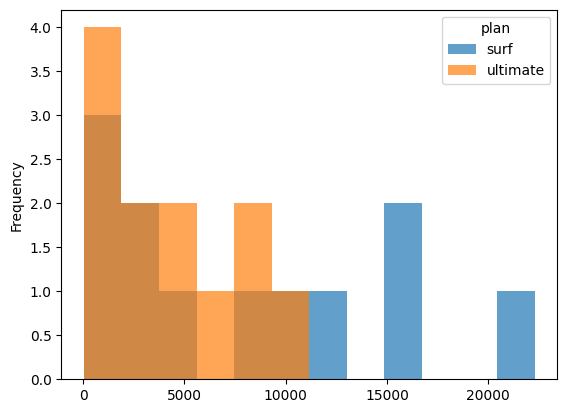

In [ ]:
sum_income_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='income',
    aggfunc='sum'
)

sum_income_pivot.plot(
    kind='hist',
    alpha=0.7,
    bins=12
)

plt.show()

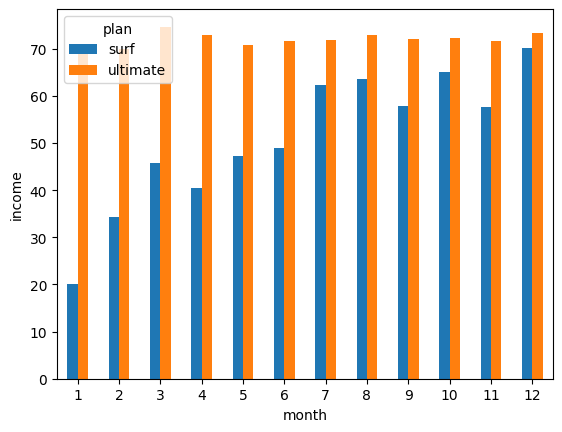

In [ ]:
mean_income_pivot = df_merged.pivot_table(
    index='month',
    columns='plan',
    values='income',
    aggfunc='mean'
)

mean_income_pivot.plot(
    kind='bar',
    rot=360,
    ylabel='income'
)

plt.show()

In [ ]:
mean_income_pivot = mean_income_pivot.rename(columns={'surf' : 'surf_mean', 'ultimate' : 'ultimate_mean'})

var_income_pivot = df_merged.pivot_table(
    columns='plan',
    index='month',
    values='income',
    aggfunc=np.var
)

var_income_pivot = var_income_pivot.rename(columns={'surf': 'surf_var', 'ultimate' : 'ultimate_var'})

income_concat = pd.concat([mean_income_pivot, var_income_pivot], axis='columns')
income_concat['general_mean'] = df_merged.groupby('month')['income'].mean()
income_concat['general_var'] = df_merged.groupby('month')['income'].agg(np.var)

Ao analisar a média de receita mensal de cada plano, foram encontradas disparidades durante todo o ano com o plano Ultimate, com ampla liderança na receita.

## Teste hipóteses estatísticas

In [ ]:
# Teste as hipóteses
income_surf = df_merged['income'].where(df_merged['plan'] == 'surf').dropna()
income_ultimate = df_merged['income'].where(df_merged['plan'] == 'ultimate').dropna()

alpha = 0.05

results = st.ttest_ind(income_surf, income_ultimate, equal_var=False)

print('valor.p: ', results.pvalue)

if results.pvalue < alpha:
  print('Hipótese nula rejeitada: a receita média dos planos são diferentes.')
else:
  print('Não pode-se rejeitar a hipótese nula: a receita média dos planos são iguais.')


valor.p:  3.6278039040985444e-16
Hipótese nula rejeitada: a receita média dos planos são diferentes.


In [ ]:
# Teste as hipóteses
cities = df_users[['user_id', 'city']]
df_merged_cities = df_merged.merge(cities, on='user_id')

ny_nj_income = df_merged_cities['income'].where(df_merged_cities['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA').dropna()
others_regions_income = df_merged_cities['income'].where(df_merged_cities['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA').dropna()

alpha = 0.05

results = st.ttest_ind(ny_nj_income, others_regions_income, equal_var=False)

print('valor.p: ', results.pvalue)

if results.pvalue < alpha:
  print('Hipótese nula rejeitada: a receita média dos usuários da área de NY-NJ são diferentes dos usuários das demais regiões.')
else:
  print('Não pode-se rejeitar a hipótese nula: a receita média dos usuários da área de NY-NJ são iguais dos usuários das demais regiões.')


valor.p:  0.031237788444585222
Hipótese nula rejeitada: a receita média dos usuários da área de NY-NJ são diferentes dos usuários das demais regiões.


Após análise da amostra dos 500 clientes fornecida pela Megaline, é possível constatar que o plano pré-pago Ultimate traz mais receitas que o plano Surf. O teste de hipóteses também aponta este resultado. Apesar do plano Surf ser mais simples e econômico, a maior parte dos usuário excedem os limites estabelecidos com pacotes extras de internet, minutos e mensagens, enquanto isso já isso pouco ocorre com o plano Ultimate. Como forma de rentabilizar mais o plano Surf, a empresa poderia considerar mudanças de valores nos pacotes extras, ou elevar o preço base.